# Monte Carlo Cost-Benefit Analysis with Sobol Sensitivity Indices — Method Demo

**What this is.** A fully self-contained, reproducible demonstration of the method I used at CIRAD/CGIAR to evaluate an agricultural subsidy under uncertainty: Monte Carlo simulation (10,000 draws) over uncertain economic parameters, full NPV and IRR distributions instead of a single point estimate, and Sobol sensitivity indices to identify which parameters actually drive the result.

**What this is not.** The real analysis and its data are confidential (CIRAD/CGIAR). Every parameter below is **synthetic and illustrative** — the numbers demonstrate the method, not any real-world finding.

Everything runs from scratch in ~30 seconds with fixed seeds; no external data required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol

rng = np.random.default_rng(42)
N_DRAWS = 10_000
HORIZON = 15  # years
DISCOUNT_RATE = 0.06

## 1. Uncertain parameters

Twelve parameters, each with a plausible distribution (triangular or normal). In the real exercise these came from field survey estimates and the literature; here they are invented for the demo.

In [2]:
# name: (distribution sampler) — all units are illustrative
def sample_params(n, rng):
    return {
        "subsidy_cost_per_ha":   rng.triangular(50, 70, 95, n),       # $/ha/yr
        "adoption_rate_peak":    rng.triangular(0.25, 0.45, 0.65, n), # share of farmers
        "adoption_speed":        rng.triangular(0.2, 0.35, 0.6, n),   # logistic rate
        "yield_gain":            rng.triangular(0.10, 0.20, 0.35, n), # relative
        "baseline_yield":        rng.normal(2.4, 0.3, n).clip(1.2),   # t/ha
        "crop_price":            rng.triangular(180, 240, 340, n),    # $/t
        "price_trend":           rng.normal(0.0, 0.01, n),            # yearly drift
        "input_cost_increase":   rng.triangular(5, 15, 30, n),        # $/ha/yr
        "admin_cost_share":      rng.triangular(0.05, 0.10, 0.18, n), # overhead on subsidy
        "environmental_cost":    rng.triangular(0, 8, 20, n),         # $/ha/yr externality
        "area_eligible":         rng.triangular(60_000, 90_000, 120_000, n),  # ha
        "dropout_rate":          rng.triangular(0.0, 0.04, 0.10, n),  # yearly disadoption
    }

params = sample_params(N_DRAWS, rng)
print({k: f"{v.mean():.3g}" for k, v in list(params.items())[:4]})

{'subsidy_cost_per_ha': '71.6', 'adoption_rate_peak': '0.451', 'adoption_speed': '0.384', 'yield_gain': '0.217'}


## 2. Cost-benefit model

A deliberately simple annual cash-flow model: adoption follows a logistic ramp to its peak, benefits are the value of the yield gain on adopted hectares net of extra input costs, costs are the subsidy bill plus administration and an environmental externality term.

In [3]:
def benefit_cost_components(p, horizon=HORIZON):
    """Vectorized: returns (benefits, costs) matrices of shape (n_draws, horizon)."""
    years = np.arange(1, horizon + 1)[None, :]                      # (1, T)
    ramp = 1.0 / (1.0 + np.exp(-p["adoption_speed"][:, None] * (years - 5)))
    adoption = p["adoption_rate_peak"][:, None] * ramp
    adoption = adoption * (1 - p["dropout_rate"][:, None]) ** years  # gradual disadoption
    area = p["area_eligible"][:, None] * adoption                    # adopted ha

    price_t = p["crop_price"][:, None] * (1 + p["price_trend"][:, None]) ** years
    benefits = area * (p["baseline_yield"][:, None] * p["yield_gain"][:, None] * price_t
                       - p["input_cost_increase"][:, None])
    costs = area * p["subsidy_cost_per_ha"][:, None] * (1 + p["admin_cost_share"][:, None]) \
            + area * p["environmental_cost"][:, None]
    return benefits, costs

def net_flows(p, horizon=HORIZON):
    b, c = benefit_cost_components(p, horizon)
    return b - c

flows = net_flows(params)
disc = (1 + DISCOUNT_RATE) ** -np.arange(1, HORIZON + 1)
npv = flows @ disc
print(f"NPV: mean {npv.mean()/1e6:.1f} M$, P(NPV<0) = {(npv < 0).mean():.1%}")

NPV: mean 4.3 M$, P(NPV<0) = 28.9%


In [4]:
# Benefit-Cost Ratio distribution (discounted benefits / discounted costs)
benefits, costs = benefit_cost_components(params)
bcr = (benefits @ disc) / (costs @ disc)
print(f"BCR: median {np.median(bcr):.2f}, P(BCR<1) = {(bcr < 1).mean():.1%}")

BCR: median 1.26, P(BCR<1) = 28.9%


## 3. Full distributions, not point estimates

The decision-relevant outputs: the entire NPV distribution and the probability the subsidy destroys value.

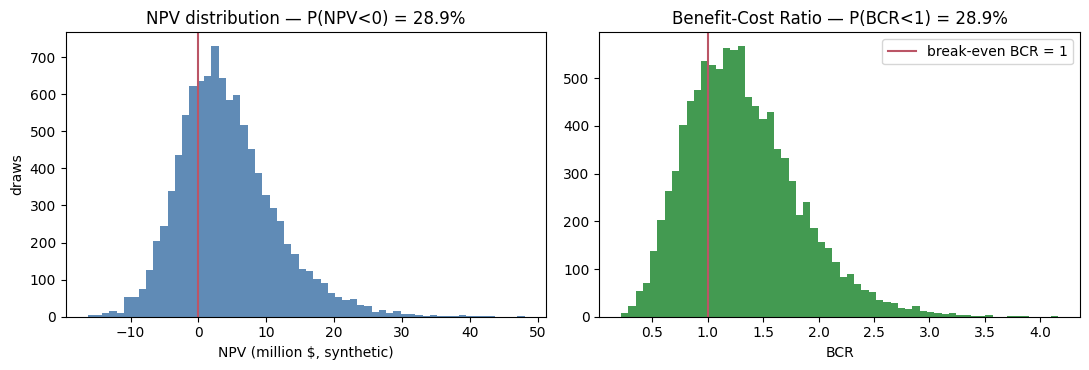

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(npv / 1e6, bins=60, color="#4477AA", alpha=0.85)
axes[0].axvline(0, color="#BB5566", lw=1.5)
axes[0].set_title(f"NPV distribution — P(NPV<0) = {(npv<0).mean():.1%}")
axes[0].set_xlabel("NPV (million $, synthetic)"); axes[0].set_ylabel("draws")
axes[1].hist(bcr, bins=60, color="#228833", alpha=0.85)
axes[1].axvline(1.0, color="#BB5566", lw=1.5, label="break-even BCR = 1")
axes[1].set_title(f"Benefit-Cost Ratio — P(BCR<1) = {(bcr<1).mean():.1%}")
axes[1].set_xlabel("BCR"); axes[1].legend()
plt.tight_layout(); plt.savefig("figures/mc_distributions.png", dpi=120, bbox_inches="tight"); plt.show()

## 4. Sobol sensitivity indices

Which of the twelve uncertain parameters actually drive the NPV? Saltelli sampling + first-order and total-order Sobol indices.

In [6]:
problem = {
    "num_vars": 12,
    "names": list(params.keys()),
    "bounds": [[50,95],[0.25,0.65],[0.2,0.6],[0.10,0.35],[1.5,3.3],[180,340],
               [-0.03,0.03],[5,30],[0.05,0.18],[0,20],[60_000,120_000],[0.0,0.10]],
}
X = sobol_sample.sample(problem, 1024, calc_second_order=False)  # (N*(D+2), 12) evaluations

def npv_from_matrix(X):
    p = {k: X[:, i] for i, k in enumerate(problem["names"])}
    return net_flows(p) @ disc

Y = npv_from_matrix(X)
Si = sobol.analyze(problem, Y, calc_second_order=False, seed=42)
order = np.argsort(Si["ST"])[::-1]
for i in order[:6]:
    print(f"{problem['names'][i]:24s} S1={Si['S1'][i]:6.3f}  ST={Si['ST'][i]:6.3f}")

yield_gain               S1= 0.335  ST= 0.480
baseline_yield           S1= 0.165  ST= 0.218
crop_price               S1= 0.109  ST= 0.163
price_trend              S1= 0.058  ST= 0.094
adoption_rate_peak       S1= 0.010  ST= 0.073
dropout_rate             S1= 0.015  ST= 0.068


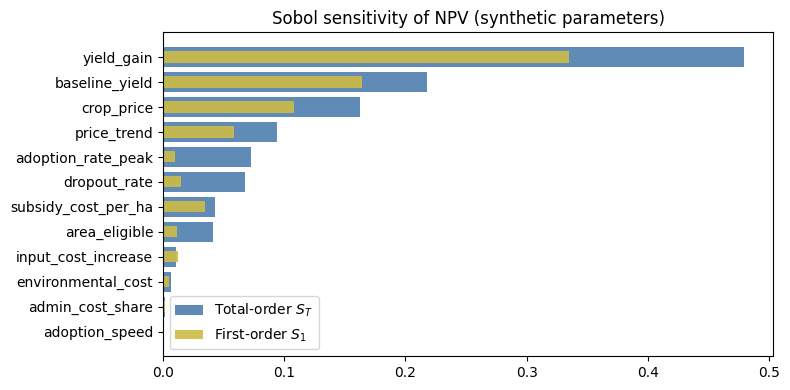

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
names = [problem["names"][i] for i in order]
ax.barh(names[::-1], Si["ST"][order][::-1], color="#4477AA", alpha=0.85, label="Total-order $S_T$")
ax.barh(names[::-1], Si["S1"][order][::-1], color="#CCBB44", alpha=0.9, height=0.45, label="First-order $S_1$")
ax.set_title("Sobol sensitivity of NPV (synthetic parameters)")
ax.legend(); plt.tight_layout(); plt.savefig("figures/mc_sobol.png", dpi=120, bbox_inches="tight"); plt.show()

## Takeaway

The method turns "is the subsidy worth it?" into (a) a probability statement about value creation and (b) a ranked list of which uncertainties matter enough to invest in measuring better. In the real CIRAD/CGIAR application, this is what allowed 20+ member organisations to reason about the decision under explicit uncertainty rather than around a single contested point estimate.